In [1]:
# this file will create AUC_graphs and AUC_data directories
# this code is the final version of the code that creates the area under the curve and data



[INFO] Graphs → C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\AUC_graph
[INFO] Data → C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\AUC_data


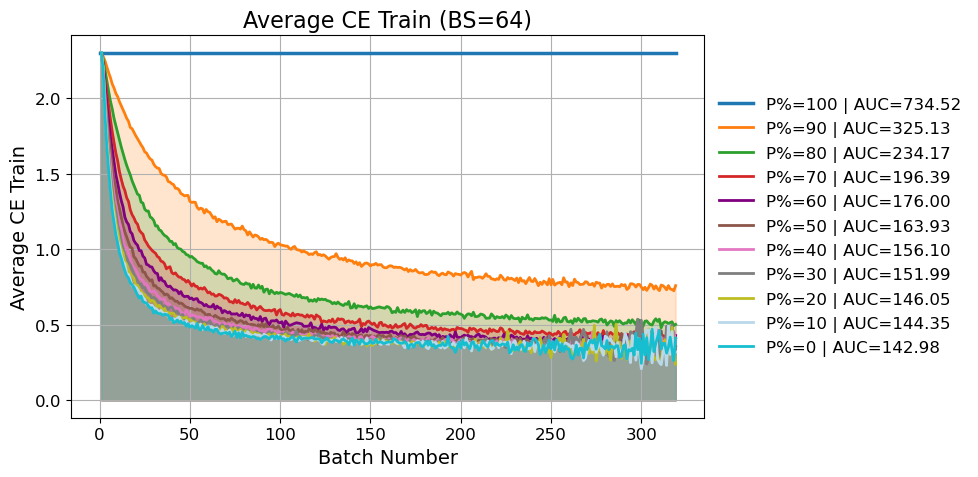

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\AUC_graph\Avg_CE_Train_BS_64.png


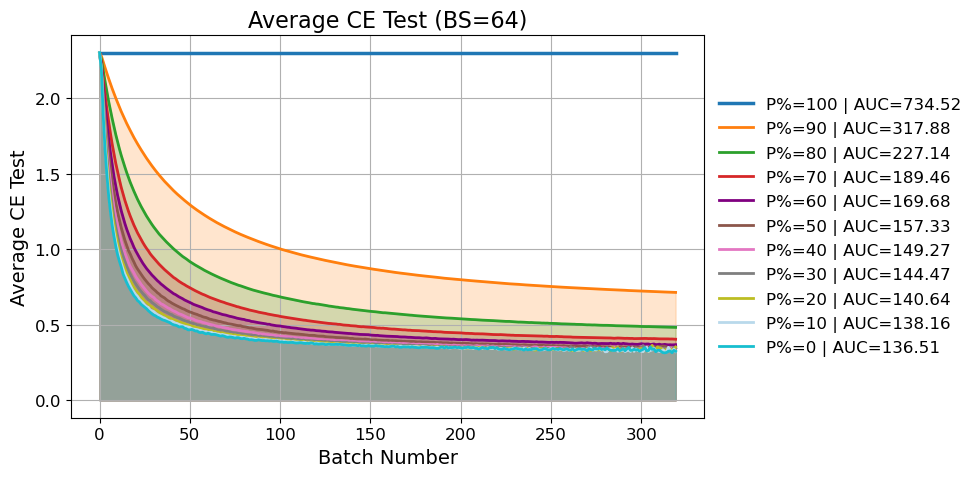

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\AUC_graph\Avg_CE_Test_BS_64.png


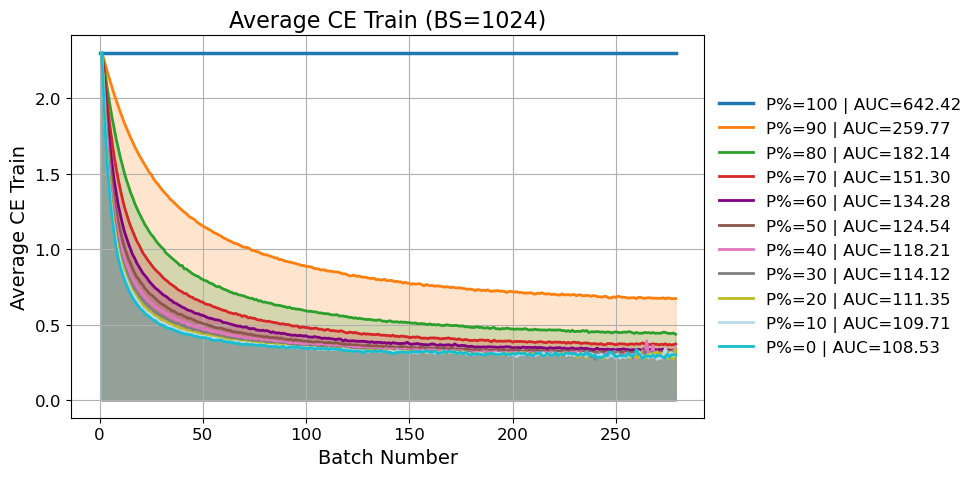

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\AUC_graph\Avg_CE_Train_BS_1024.png


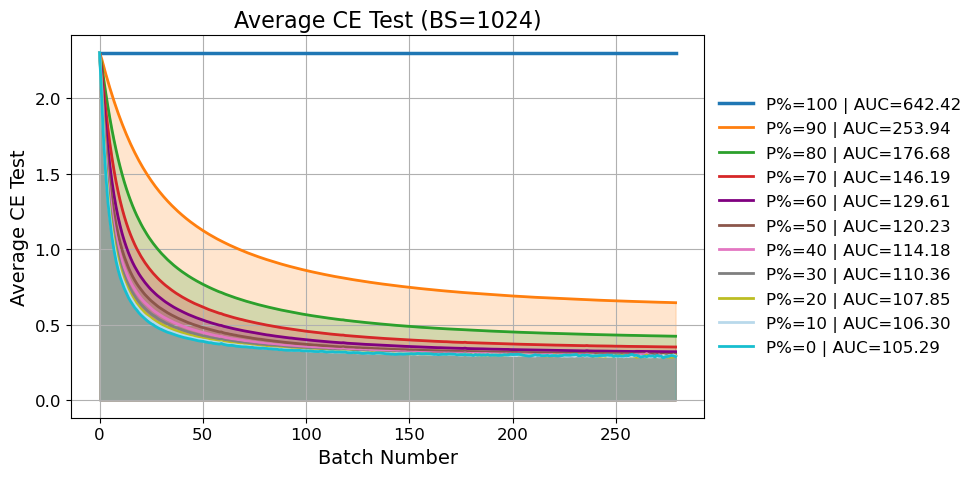

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\AUC_graph\Avg_CE_Test_BS_1024.png


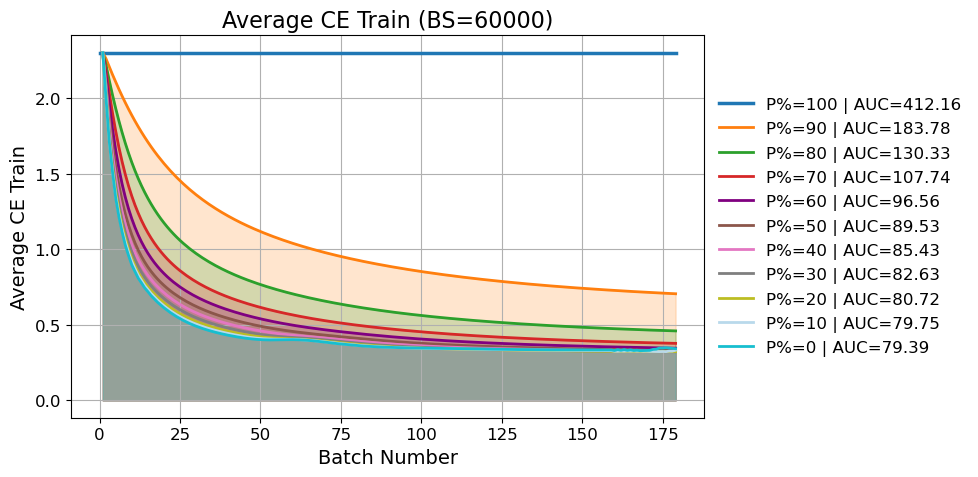

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\AUC_graph\Avg_CE_Train_BS_60000.png


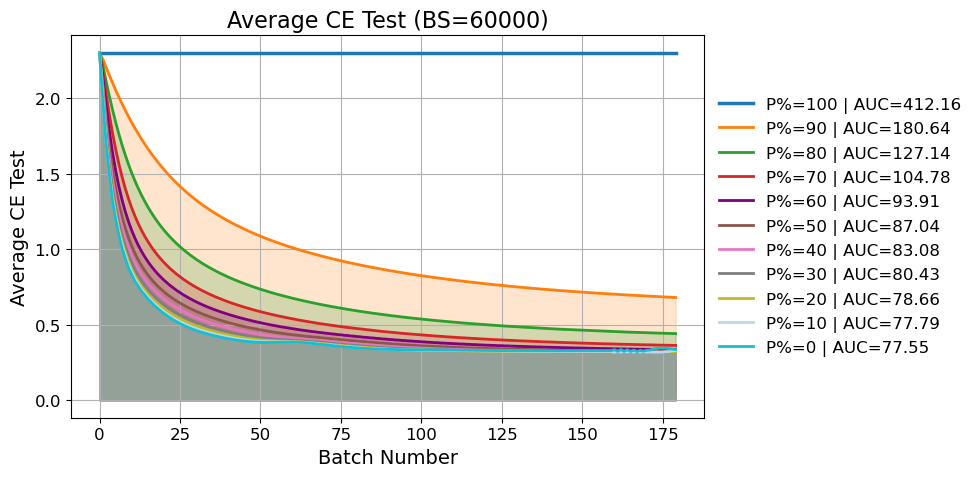

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\AUC_graph\Avg_CE_Test_BS_60000.png
[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\AUC_data\AUC_ALL_BS.csv

✅ All AUC graphs and combined data saved successfully.


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG (SLP-MNIST)
# =========================
BASE_DIR_ROOT = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST"
BATCH_DIR_TEMPLATE = "prune_layers_ALL\\p-percentage_{:.1f}\\batch_size_{}"

BATCH_SIZES = [64, 1024, 60000]  # add/remove batch sizes as needed
PRUNING_PERCENTAGES = [round(x * 0.1, 1) for x in range(0, 11)]  # 0.0 → 1.0

# =========================
# OUTPUT DIRECTORIES
# =========================
AUC_GRAPH_DIR = os.path.join(BASE_DIR_ROOT, "AUC_graph")
AUC_DATA_DIR = os.path.join(BASE_DIR_ROOT, "AUC_data")
os.makedirs(AUC_GRAPH_DIR, exist_ok=True)
os.makedirs(AUC_DATA_DIR, exist_ok=True)
print(f"[INFO] Graphs → {AUC_GRAPH_DIR}")
print(f"[INFO] Data → {AUC_DATA_DIR}")

# =========================
# STYLE
# =========================
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# Maximum CE cap
CE_MAX = np.log(10)  # ≈ 2.3026

# =========================
# DEFINE COLORS
# =========================
COLOR_LIST = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#800080",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#B9D9EB", "#17becf"
]

# =========================
# MAIN LOOP
# =========================
all_auc_records = []  # single list for both CE types

for bs in BATCH_SIZES:

    avg_dfs = {}

    # -------------------------
    # LOAD AVERAGED FILES
    # -------------------------
    for p in PRUNING_PERCENTAGES:
        folder = os.path.join(BASE_DIR_ROOT, BATCH_DIR_TEMPLATE.format(p, bs))
        file_path = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")

        if not os.path.isfile(file_path):
            print(f"[WARNING] File not found: {file_path}")
            continue

        df = pd.read_csv(file_path)
        # Cap CE values
        df["Avg_CE_Train"] = np.minimum(df["Avg_CE_Train"], CE_MAX)
        df["Avg_CE_Test"] = np.minimum(df["Avg_CE_Test"], CE_MAX)

        avg_dfs[p] = df

    if not avg_dfs:
        print(f"[WARNING] No data found for BS={bs}")
        continue

    # -------------------------
    # Find lowest max Batch_Number (exclude 100%)
    # -------------------------
    non100_dfs = {p: df for p, df in avg_dfs.items() if p != 1.0}
    if non100_dfs:
        lowest_max_batch = min(df["Batch_Number"].max() for df in non100_dfs.values())
    else:
        lowest_max_batch = min(df["Batch_Number"].max() for df in avg_dfs.values())

    # -------------------------
    # PLOT FUNCTION
    # -------------------------
    def plot_and_save_ce(avg_dfs, bs, ce_column, title):

        plt.figure(figsize=(10, 5))
        plt.title(f"{title} (BS={bs})")
        plt.xlabel("Batch Number")
        plt.ylabel(title)

        for i, p in enumerate(sorted(avg_dfs.keys(), reverse=True)):
            df = avg_dfs[p]
            color = COLOR_LIST[i % len(COLOR_LIST)]

            if p == 1.0:
                ce_value = df[ce_column].iloc[-1]
                ce_value = min(ce_value, CE_MAX)
                x = np.array([0, lowest_max_batch])
                y = np.array([ce_value, ce_value])
                auc = ce_value * lowest_max_batch

                plt.plot(x, y, color=color, linewidth=2.5,
                         label=f"P%={int(p*100)} | AUC={auc:.2f}")

            else:
                df_trunc = df[df["Batch_Number"] <= lowest_max_batch]
                x = df_trunc["Batch_Number"].to_numpy()
                y = np.minimum(df_trunc[ce_column].to_numpy(), CE_MAX)  # cap CE

                mask = np.isfinite(x) & np.isfinite(y)
                x, y = x[mask], y[mask]

                if len(x) == 0:
                    print(f"[WARNING] NaNs only for P%={p}, BS={bs}")
                    continue

                auc = np.trapezoid(y, x)

                plt.plot(x, y, color=color, linewidth=2.0,
                         label=f"P%={int(p*100)} | AUC={auc:.2f}")
                plt.fill_between(x, y, alpha=0.2, color=color)

            # Append to global records (single CSV)
            all_auc_records.append([bs, p, ce_column, auc])

        plt.grid(True)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
        plt.tight_layout()

        # SAVE FIGURE
        fig_path = os.path.join(AUC_GRAPH_DIR, f"{ce_column}_BS_{bs}.png")
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
        print(f"[SAVED] {fig_path}")

    # -------------------------
    # Plot Train & Test
    # -------------------------
    plot_and_save_ce(avg_dfs, bs, "Avg_CE_Train", "Average CE Train")
    plot_and_save_ce(avg_dfs, bs, "Avg_CE_Test", "Average CE Test")

# -------------------------
# SAVE SINGLE CSV FOR ALL
# -------------------------
if all_auc_records:
    auc_df = pd.DataFrame(all_auc_records, columns=["Batch_Size", "Pruning_Percentage", "CE_Type", "AUC"])
    csv_path = os.path.join(AUC_DATA_DIR, "AUC_ALL_BS.csv")
    auc_df.to_csv(csv_path, index=False)
    print(f"[SAVED] {csv_path}")

print("\n✅ All AUC graphs and combined data saved successfully.")


C:\Users\Student\AppData\Local\Temp\ipykernel_17980\2227923018.py:127: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)


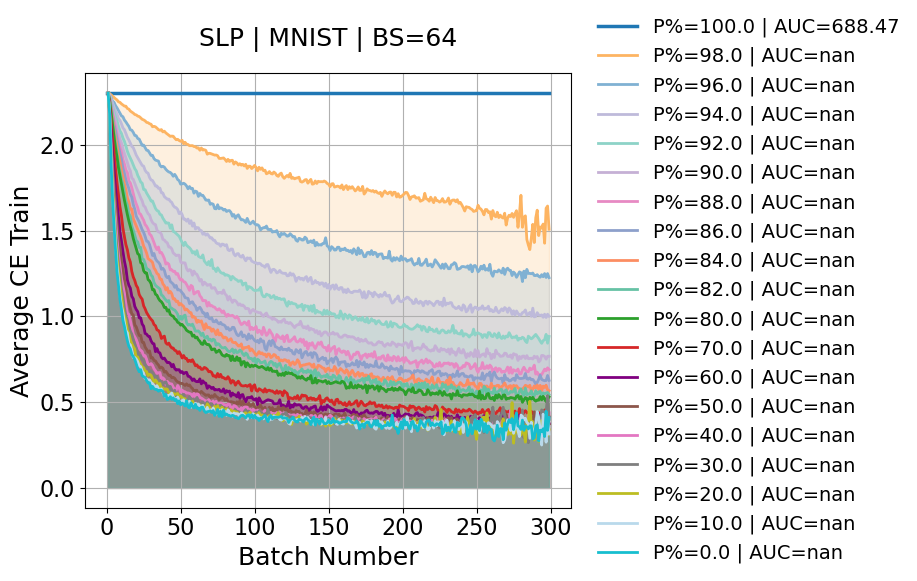

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Train_BS_64.png


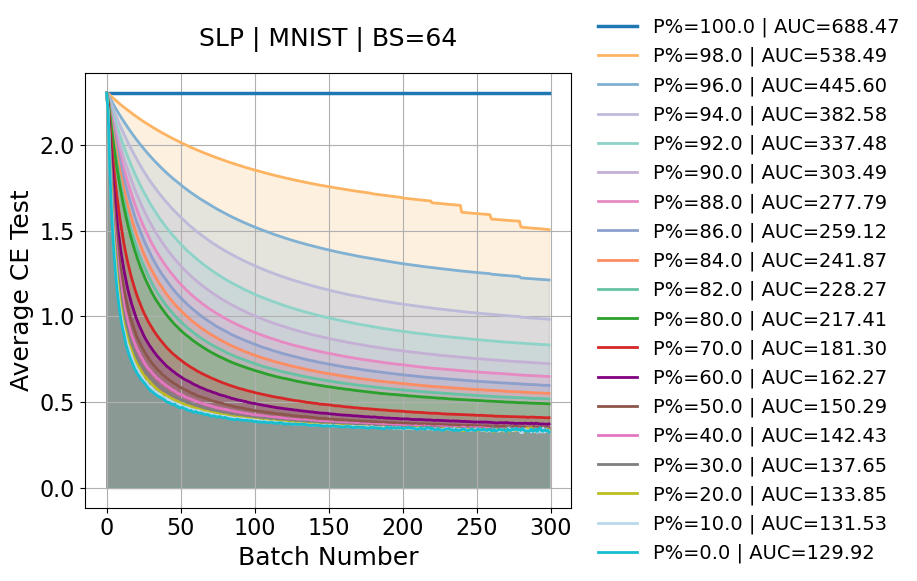

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Test_BS_64.png


C:\Users\Student\AppData\Local\Temp\ipykernel_17980\2227923018.py:127: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)


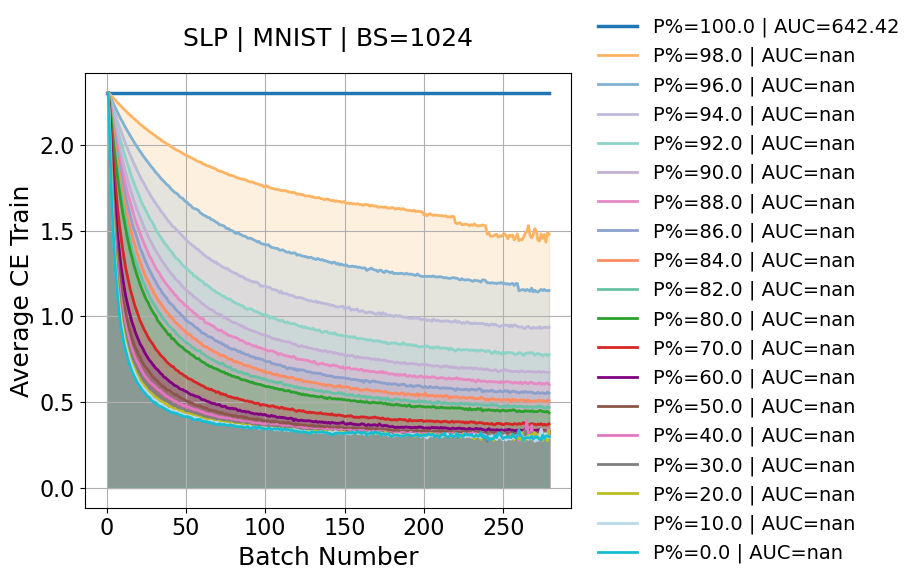

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Train_BS_1024.png


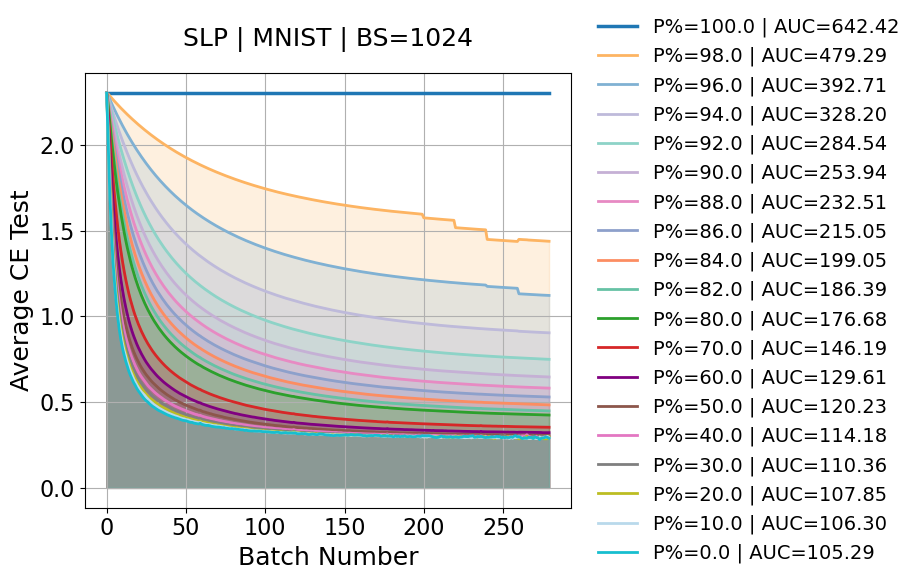

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Test_BS_1024.png


C:\Users\Student\AppData\Local\Temp\ipykernel_17980\2227923018.py:127: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)


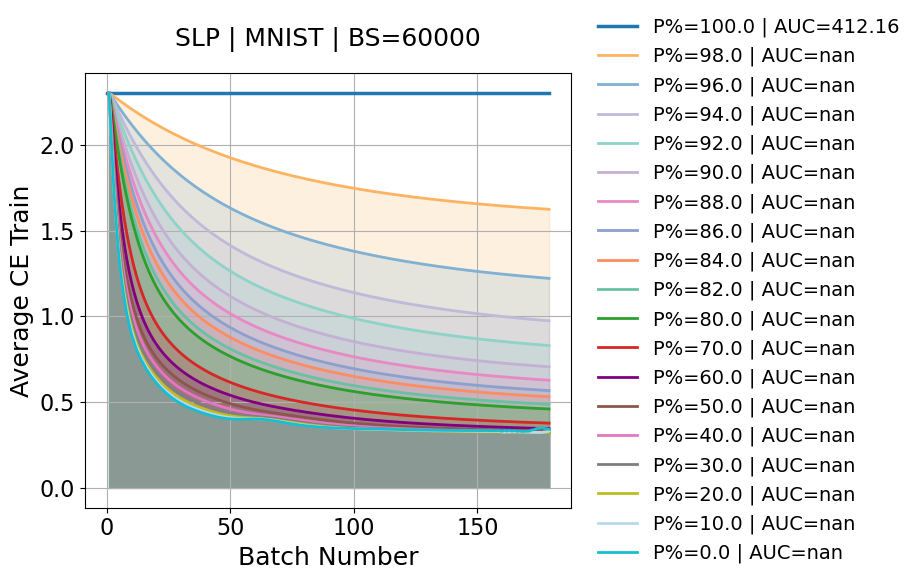

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Train_BS_60000.png


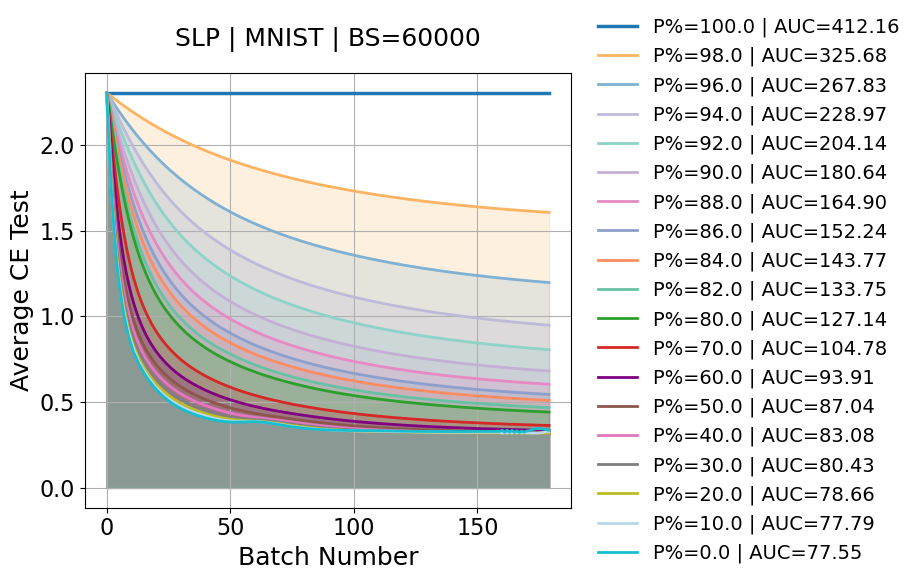

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Test_BS_60000.png
[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_data\AUC_ALL_BS.csv

✅ All AUC graphs and data saved successfully.


In [6]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL"
BATCH_DIR_TEMPLATE = "p-percentage_{}\\batch_size_{}"
BATCH_SIZES = [64, 1024, 60000]
PRUNING_PERCENTAGES = [
    0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,
    0.8, 0.82, 0.84, 0.86, 0.88, 0.9, 0.92, 0.94, 0.96, 0.98, 1.0
]
CE_MAX = np.log(10)  # Cap CE values at ln(10)

# =========================
# STANDARD COLOR MAP
# =========================
PRUNING_COLOR_MAP = {
    0.0:   "#17becf",
    0.1:   "#B9D9EB",
    0.2:   "#bcbd22",
    0.3:   "#7f7f7f",
    0.4:   "#e377c2",
    0.5:   "#8c564b",
    0.6:   "#800080",
    0.7:   "#d62728",
    0.8:   "#2ca02c",
    0.82:  "#66c2a5",
    0.84:  "#fc8d62",
    0.86:  "#8da0cb",
    0.88:  "#e78ac3",
    0.9:   "#C5B0D5",
    0.92:  "#8DD3C7",
    0.94:  "#BEBADA",
    0.96:  "#80B1D3",
    0.98:  "#FDB462",
    0.985: "#6A5ACD",
    0.99:  "#FF6F61",
    1.0:   "#1f77b4"
}

# =========================
# OUTPUT DIRECTORIES
# =========================
AUC_GRAPH_DIR = os.path.join(BASE_DIR, "AUC_graph")
AUC_DATA_DIR = os.path.join(BASE_DIR, "AUC_data")
os.makedirs(AUC_GRAPH_DIR, exist_ok=True)
os.makedirs(AUC_DATA_DIR, exist_ok=True)

# =========================
# STYLE
# =========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14
})

# =========================
# MAIN LOOP
# =========================
all_auc_records = []

for bs in BATCH_SIZES:
    avg_dfs = {}

    # -------------------------
    # LOAD AVERAGED FILES
    # -------------------------
    for p in PRUNING_PERCENTAGES:
        folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
        file_path = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")

        if not os.path.isfile(file_path):
            print(f"[WARNING] File not found: {file_path}")
            continue

        df = pd.read_csv(file_path)
        df["Avg_CE_Train"] = np.minimum(df["Avg_CE_Train"], CE_MAX)
        df["Avg_CE_Test"] = np.minimum(df["Avg_CE_Test"], CE_MAX)
        avg_dfs[p] = df

    if not avg_dfs:
        print(f"[WARNING] No data found for BS={bs}")
        continue

    # -------------------------
    # Find lowest max Batch_Number (exclude p=1.0)
    # -------------------------
    non100_dfs = {p: df for p, df in avg_dfs.items() if p != 1.0}
    if non100_dfs:
        lowest_max_batch = min(df["Batch_Number"].max() for df in non100_dfs.values())
    else:
        lowest_max_batch = min(df["Batch_Number"].max() for df in avg_dfs.values())

    # -------------------------
    # PLOT FUNCTION
    # -------------------------
    def plot_auc(metric_col, ylabel):
        plt.figure(figsize=(12, 6))
        plt.xlabel("Batch Number")
        plt.ylabel(ylabel)
        plt.title(f"SLP | MNIST | BS={bs}", pad=20)

        for p in sorted(avg_dfs.keys(), reverse=True):
            df = avg_dfs[p]
            color = PRUNING_COLOR_MAP.get(p, "#000000")

            if p == 1.0:
                y_val = df[metric_col].iloc[-1]
                x = np.array([0, lowest_max_batch])
                y = np.array([y_val, y_val])
                auc = y_val * lowest_max_batch
                plt.plot(x, y, color=color, linewidth=2.5,
                         label=f"P%={round(p*100, 2)} | AUC={auc:.2f}")
            else:
                df_trunc = df[df["Batch_Number"] <= lowest_max_batch]
                x = df_trunc["Batch_Number"].to_numpy()
                y = df_trunc[metric_col].to_numpy()
                auc = np.trapz(y, x)
                plt.plot(x, y, color=color, linewidth=2.0,
                         label=f"P%={round(p*100, 2)} | AUC={auc:.2f}")
                plt.fill_between(x, y, alpha=0.2, color=color)

            # Save AUC record
            all_auc_records.append([bs, p, metric_col, auc])

        plt.grid(True)
        plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
        plt.tight_layout(rect=[0, 0, 0.80, 1])

        # Save figure
        fig_path = os.path.join(AUC_GRAPH_DIR, f"{metric_col}_BS_{bs}.png")
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
        print(f"[SAVED] {fig_path}")

    # -------------------------
    # Plot CE Train & Test
    # -------------------------
    plot_auc("Avg_CE_Train", "Average CE Train")
    plot_auc("Avg_CE_Test", "Average CE Test")

# -------------------------
# SAVE ALL AUC DATA
# -------------------------
if all_auc_records:
    auc_df = pd.DataFrame(all_auc_records, columns=["Batch_Size", "Pruning_Percentage", "CE_Type", "AUC"])
    csv_path = os.path.join(AUC_DATA_DIR, "AUC_ALL_BS.csv")
    auc_df.to_csv(csv_path, index=False)
    print(f"[SAVED] {csv_path}")

print("\n✅ All AUC graphs and data saved successfully.")

C:\Users\Student\AppData\Local\Temp\ipykernel_17980\2227923018.py:127: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)


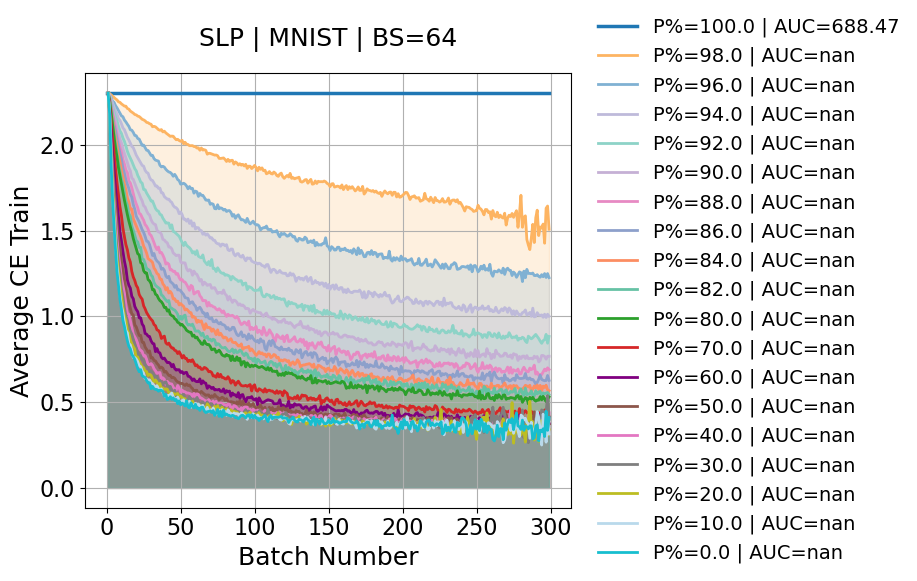

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Train_BS_64.png


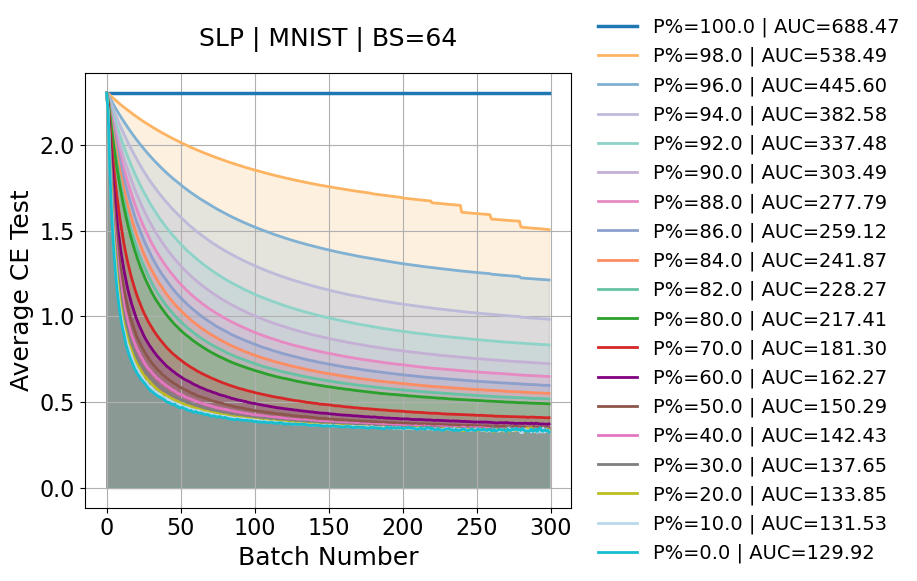

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Test_BS_64.png


C:\Users\Student\AppData\Local\Temp\ipykernel_17980\2227923018.py:127: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)


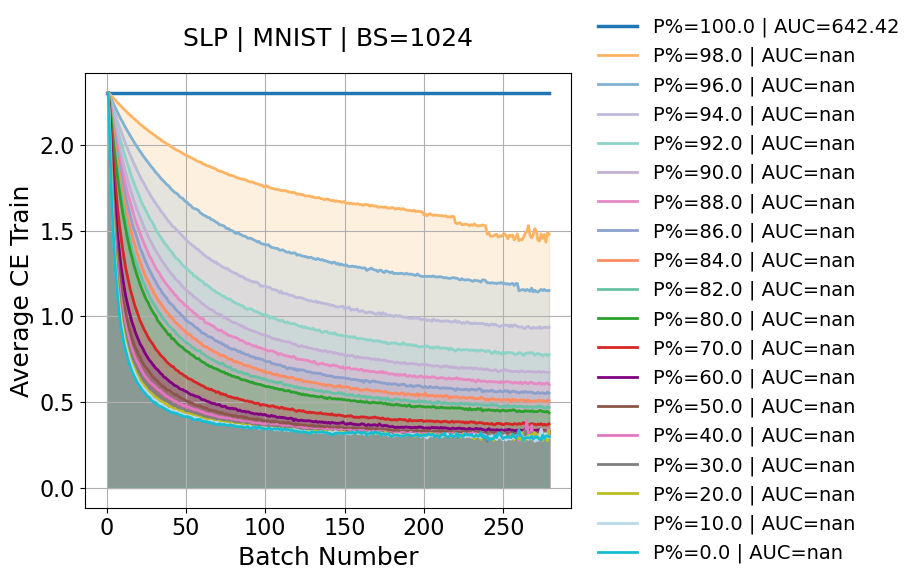

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Train_BS_1024.png


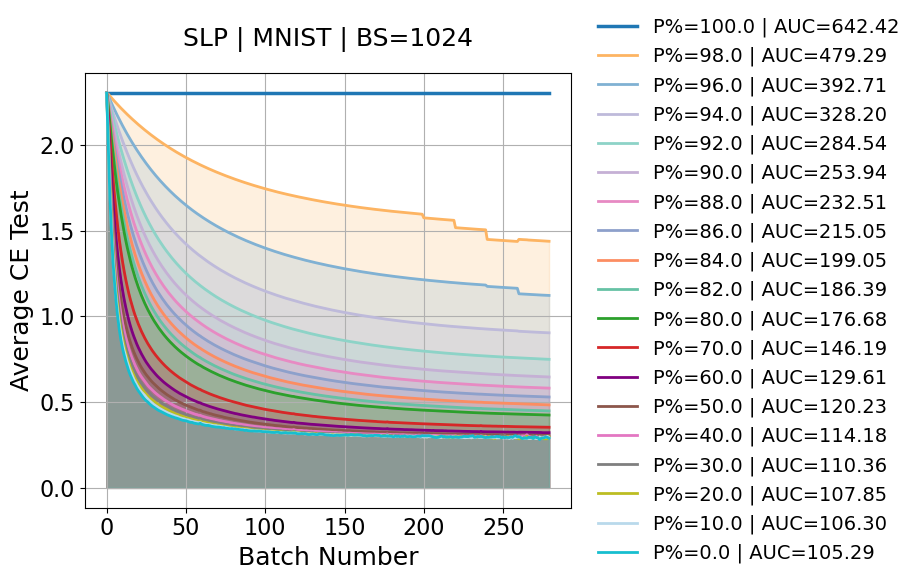

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Test_BS_1024.png


C:\Users\Student\AppData\Local\Temp\ipykernel_17980\2227923018.py:127: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)


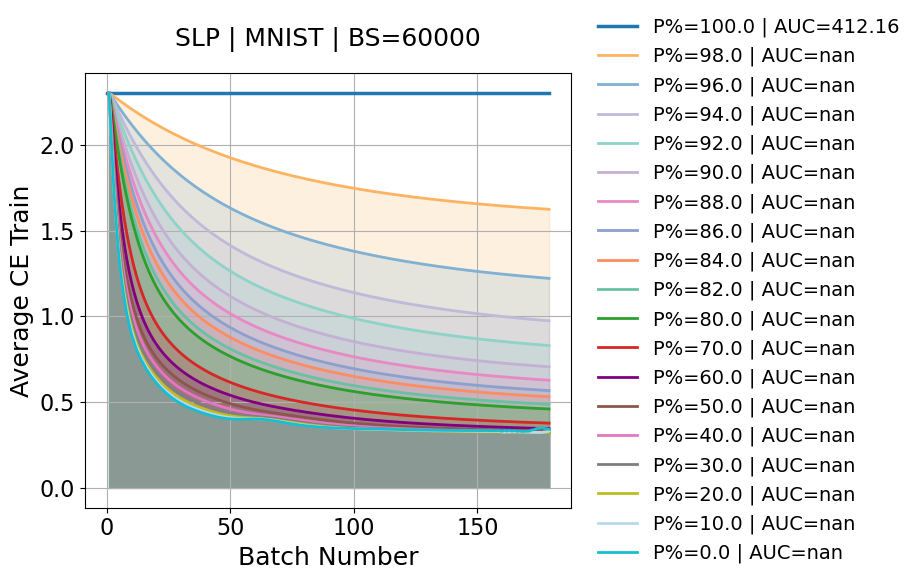

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Train_BS_60000.png


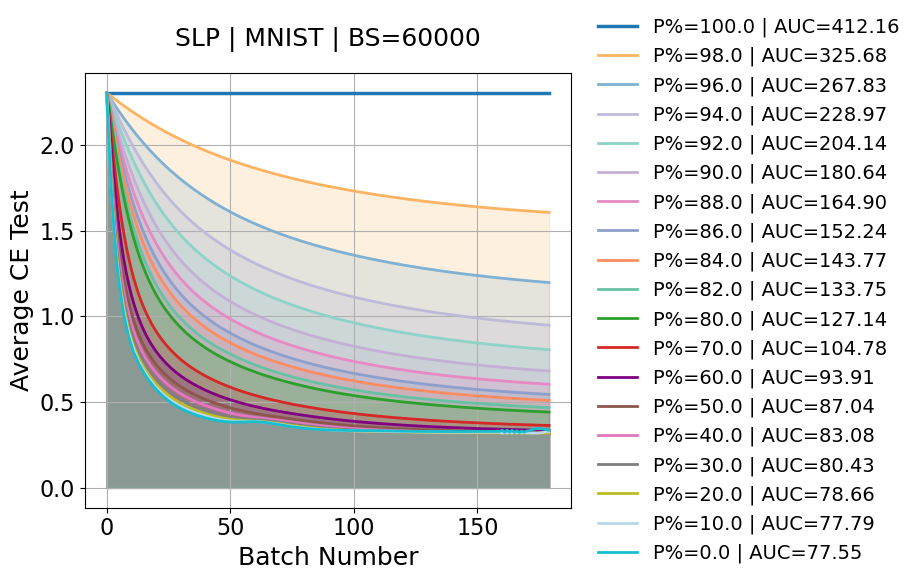

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Test_BS_60000.png
[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_data\AUC_ALL_BS.csv

✅ All AUC graphs and data saved successfully.


In [7]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL"
BATCH_DIR_TEMPLATE = "p-percentage_{}\\batch_size_{}"
BATCH_SIZES = [64, 1024, 60000]
PRUNING_PERCENTAGES = [
    0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,
    0.8, 0.82, 0.84, 0.86, 0.88, 0.9, 0.92, 0.94, 0.96, 0.98, 1.0
]
CE_MAX = np.log(10)  # Cap CE values at ln(10)

# =========================
# STANDARD COLOR MAP
# =========================
PRUNING_COLOR_MAP = {
    0.0:   "#17becf",
    0.1:   "#B9D9EB",
    0.2:   "#bcbd22",
    0.3:   "#7f7f7f",
    0.4:   "#e377c2",
    0.5:   "#8c564b",
    0.6:   "#800080",
    0.7:   "#d62728",
    0.8:   "#2ca02c",
    0.82:  "#66c2a5",
    0.84:  "#fc8d62",
    0.86:  "#8da0cb",
    0.88:  "#e78ac3",
    0.9:   "#C5B0D5",
    0.92:  "#8DD3C7",
    0.94:  "#BEBADA",
    0.96:  "#80B1D3",
    0.98:  "#FDB462",
    0.985: "#6A5ACD",
    0.99:  "#FF6F61",
    1.0:   "#1f77b4"
}

# =========================
# OUTPUT DIRECTORIES
# =========================
AUC_GRAPH_DIR = os.path.join(BASE_DIR, "AUC_graph")
AUC_DATA_DIR = os.path.join(BASE_DIR, "AUC_data")
os.makedirs(AUC_GRAPH_DIR, exist_ok=True)
os.makedirs(AUC_DATA_DIR, exist_ok=True)

# =========================
# STYLE
# =========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14
})

# =========================
# MAIN LOOP
# =========================
all_auc_records = []

for bs in BATCH_SIZES:
    avg_dfs = {}

    # -------------------------
    # LOAD AVERAGED FILES
    # -------------------------
    for p in PRUNING_PERCENTAGES:
        folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
        file_path = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")

        if not os.path.isfile(file_path):
            print(f"[WARNING] File not found: {file_path}")
            continue

        df = pd.read_csv(file_path)
        df["Avg_CE_Train"] = np.minimum(df["Avg_CE_Train"], CE_MAX)
        df["Avg_CE_Test"] = np.minimum(df["Avg_CE_Test"], CE_MAX)
        avg_dfs[p] = df

    if not avg_dfs:
        print(f"[WARNING] No data found for BS={bs}")
        continue

    # -------------------------
    # Find lowest max Batch_Number (exclude p=1.0)
    # -------------------------
    non100_dfs = {p: df for p, df in avg_dfs.items() if p != 1.0}
    if non100_dfs:
        lowest_max_batch = min(df["Batch_Number"].max() for df in non100_dfs.values())
    else:
        lowest_max_batch = min(df["Batch_Number"].max() for df in avg_dfs.values())

    # -------------------------
    # PLOT FUNCTION
    # -------------------------
    def plot_auc(metric_col, ylabel):
        plt.figure(figsize=(12, 6))
        plt.xlabel("Batch Number")
        plt.ylabel(ylabel)
        plt.title(f"SLP | MNIST | BS={bs}", pad=20)

        for p in sorted(avg_dfs.keys(), reverse=True):
            df = avg_dfs[p]
            color = PRUNING_COLOR_MAP.get(p, "#000000")

            if p == 1.0:
                y_val = df[metric_col].iloc[-1]
                x = np.array([0, lowest_max_batch])
                y = np.array([y_val, y_val])
                auc = y_val * lowest_max_batch
                plt.plot(x, y, color=color, linewidth=2.5,
                         label=f"P%={round(p*100, 2)} | AUC={auc:.2f}")
            else:
                df_trunc = df[df["Batch_Number"] <= lowest_max_batch]
                x = df_trunc["Batch_Number"].to_numpy()
                y = df_trunc[metric_col].to_numpy()
                auc = np.trapz(y, x)
                plt.plot(x, y, color=color, linewidth=2.0,
                         label=f"P%={round(p*100, 2)} | AUC={auc:.2f}")
                plt.fill_between(x, y, alpha=0.2, color=color)

            # Save AUC record
            all_auc_records.append([bs, p, metric_col, auc])

        plt.grid(True)
        plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
        plt.tight_layout(rect=[0, 0, 0.80, 1])

        # Save figure
        fig_path = os.path.join(AUC_GRAPH_DIR, f"{metric_col}_BS_{bs}.png")
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
        print(f"[SAVED] {fig_path}")

    # -------------------------
    # Plot CE Train & Test
    # -------------------------
    plot_auc("Avg_CE_Train", "Average CE Train")
    plot_auc("Avg_CE_Test", "Average CE Test")

# -------------------------
# SAVE ALL AUC DATA
# -------------------------
if all_auc_records:
    auc_df = pd.DataFrame(all_auc_records, columns=["Batch_Size", "Pruning_Percentage", "CE_Type", "AUC"])
    csv_path = os.path.join(AUC_DATA_DIR, "AUC_ALL_BS.csv")
    auc_df.to_csv(csv_path, index=False)
    print(f"[SAVED] {csv_path}")

print("\n✅ All AUC graphs and data saved successfully.")


Processing BS=64


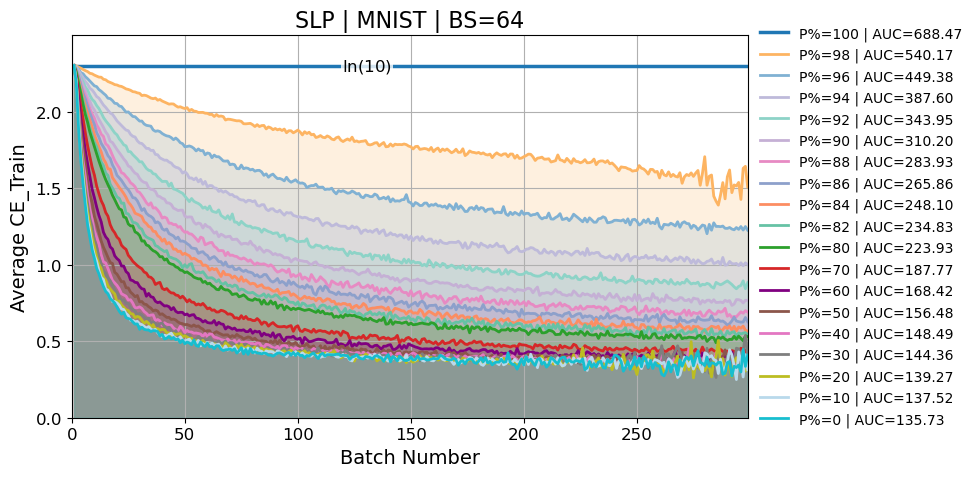

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Train_BS_64.png


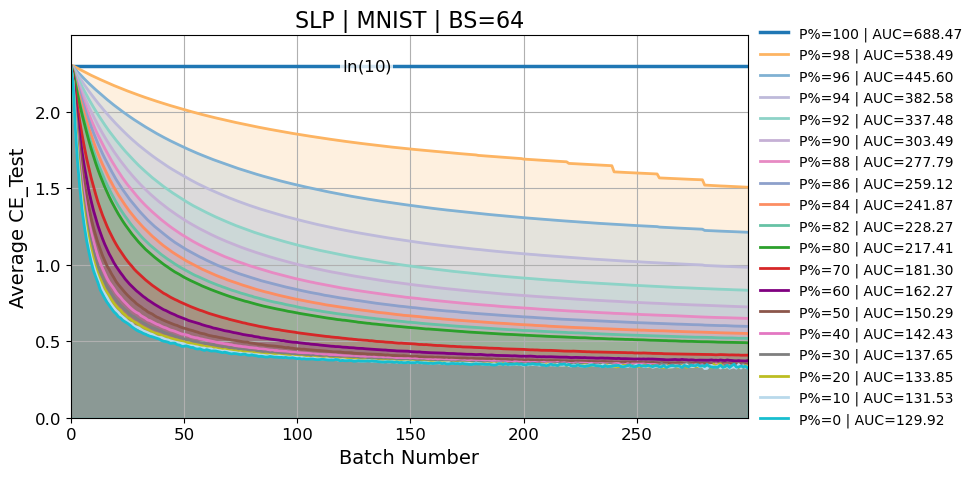

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Test_BS_64.png

Processing BS=1024


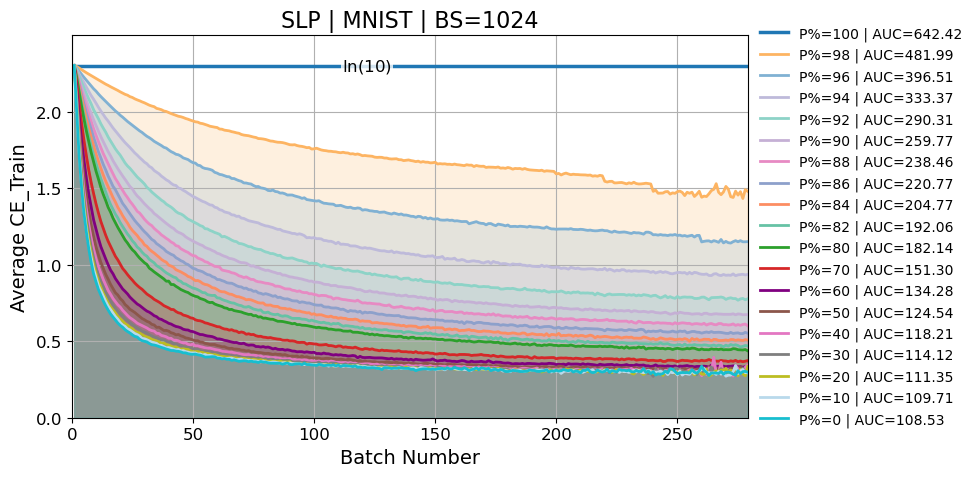

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Train_BS_1024.png


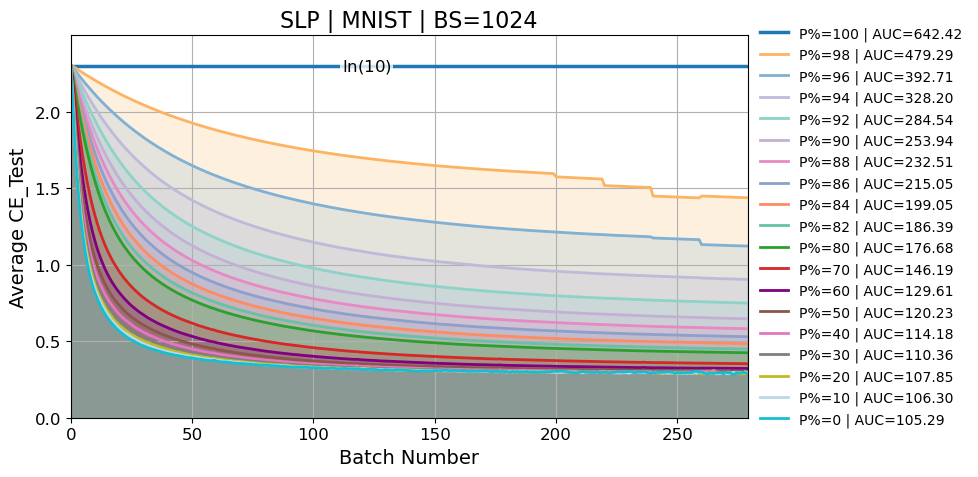

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Test_BS_1024.png

Processing BS=60000


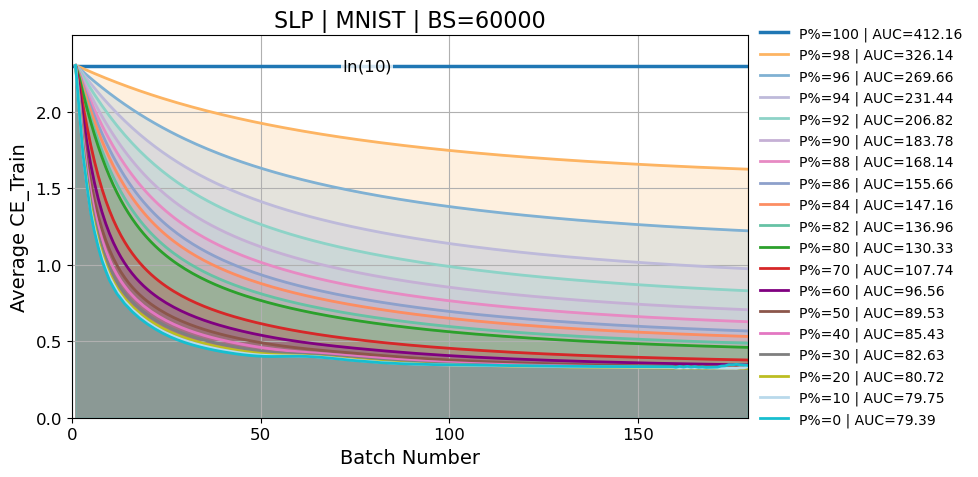

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Train_BS_60000.png


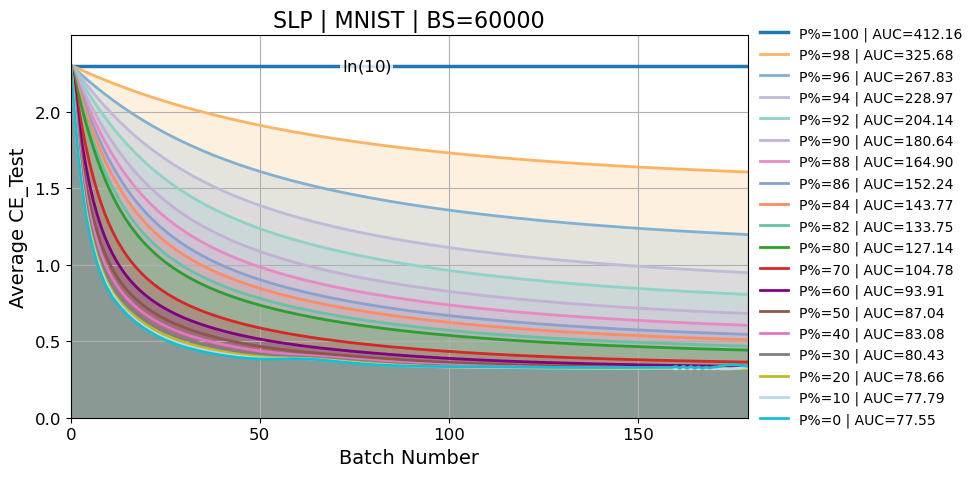

[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_graph\Avg_CE_Test_BS_60000.png
[SAVED] C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\AUC_data\AUC_ALL_BS.csv

✅ All SLP AUC graphs and data saved successfully.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL"

BATCH_SIZES = [64, 1024, 60000]

PRUNING_PERCENTAGES = [
    0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,
    0.8, 0.82, 0.84, 0.86, 0.88, 0.9,
    0.92, 0.94, 0.96, 0.98, 1.0
]

# =========================
# OUTPUT
# =========================
AUC_GRAPH_DIR = os.path.join(BASE_DIR, "AUC_graph")
AUC_DATA_DIR = os.path.join(BASE_DIR, "AUC_data")
os.makedirs(AUC_GRAPH_DIR, exist_ok=True)
os.makedirs(AUC_DATA_DIR, exist_ok=True)

# =========================
# STYLE (MATCH CNN)
# =========================
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10
})

CE_MAX = np.log(10)

# =========================
# COLOR MAP (SAME AS BEFORE)
# =========================
PRUNING_COLOR_MAP = {
    0.0:   "#17becf",
    0.1:   "#B9D9EB",
    0.2:   "#bcbd22",
    0.3:   "#7f7f7f",
    0.4:   "#e377c2",
    0.5:   "#8c564b",
    0.6:   "#800080",
    0.7:   "#d62728",
    0.8:   "#2ca02c",
    0.82:  "#66c2a5",
    0.84:  "#fc8d62",
    0.86:  "#8da0cb",
    0.88:  "#e78ac3",
    0.9:   "#C5B0D5",
    0.92:  "#8DD3C7",
    0.94:  "#BEBADA",
    0.96:  "#80B1D3",
    0.98:  "#FDB462",
    1.0:   "#1f77b4"
}

# =========================
# HELPERS (MATCH CNN)
# =========================
def label_from_p(p):
    pct = p * 100
    if abs(pct - round(pct)) < 1e-9:
        return f"P%={int(round(pct))}"
    return f"P%={pct:g}"

all_auc_records = []

# =========================
# MAIN LOOP
# =========================
for bs in BATCH_SIZES:
    print(f"\nProcessing BS={bs}")

    avg_dfs = {}

    # -------------------------
    # LOAD FILES
    # -------------------------
    for p in PRUNING_PERCENTAGES:
        file_path = os.path.join(
            BASE_DIR,
            f"p-percentage_{p}",
            f"batch_size_{bs}",
            f"averaged_runs_p_{p}_bs_{bs}.csv"
        )

        if not os.path.isfile(file_path):
            print(f"[WARNING] Missing file: {file_path}")
            continue

        avg_dfs[p] = pd.read_csv(file_path)

    if not avg_dfs:
        print(f"[WARNING] No data for BS={bs}")
        continue

    # -------------------------
    # ALIGN BATCH RANGE
    # -------------------------
    non100 = {
        p: df for p, df in avg_dfs.items()
        if p != 1.0 and "Batch_Number" in df.columns
    }
    non100 = {p: df for p, df in non100.items() if not df.empty}

    if non100:
        lowest_max_batch = min(df["Batch_Number"].max() for df in non100.values())
    else:
        lowest_max_batch = min(df["Batch_Number"].max() for df in avg_dfs.values())

    # -------------------------
    # PLOT FUNCTION (CNN STYLE)
    # -------------------------
    def plot_and_save_ce(ce_column, y_label, file_stub):

        plt.figure(figsize=(10, 5))  # MATCH CNN SIZE
        plt.title(f"SLP | MNIST | BS={bs}")
        plt.xlabel("Batch Number")
        plt.ylabel(y_label)

        plt.xlim(0, lowest_max_batch)
        plt.xticks(np.arange(0, int(lowest_max_batch) + 1, 50))
        plt.yticks(np.arange(0, 2.5, 0.5))
        plt.ylim(0, 2.5)

        # ln(10) line label
        plt.text(
            0.40,
            CE_MAX,
            r"$\ln(10)$",
            transform=plt.gca().get_yaxis_transform(),
            fontsize=12,
            va="center",
            ha="left",
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1)
        )

        for p in sorted(avg_dfs.keys(), reverse=True):
            df = avg_dfs[p].copy()
            df = df[df["Batch_Number"] <= lowest_max_batch]

            color = PRUNING_COLOR_MAP.get(p, "#000000")

            if p == 1.0:
                ce_value = min(df[ce_column].iloc[-1], CE_MAX)
                x = np.array([0, lowest_max_batch])
                y = np.array([ce_value, ce_value])
                auc = ce_value * lowest_max_batch

                plt.plot(
                    x, y,
                    color=color,
                    linewidth=2.5,
                    label=f"{label_from_p(p)} | AUC={auc:.2f}"
                )

            else:
                x = df["Batch_Number"].to_numpy()
                y = np.minimum(df[ce_column].to_numpy(), CE_MAX)

                # REMOVE NaNs (IMPORTANT)
                mask = np.isfinite(x) & np.isfinite(y)
                x, y = x[mask], y[mask]

                if len(x) == 0:
                    print(f"[WARNING] No valid data for P%={p}")
                    continue

                auc = np.trapezoid(y, x)

                plt.plot(
                    x, y,
                    color=color,
                    linewidth=2.0,
                    label=f"{label_from_p(p)} | AUC={auc:.2f}"
                )
                plt.fill_between(x, y, alpha=0.2, color=color)

            all_auc_records.append([bs, p, ce_column, auc])

        plt.grid(True)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
        plt.tight_layout()

        fig_path = os.path.join(AUC_GRAPH_DIR, f"{file_stub}_BS_{bs}.png")
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

        print(f"[SAVED] {fig_path}")

    # -------------------------
    # RUN PLOTS
    # -------------------------
    plot_and_save_ce("Avg_CE_Train", "Average CE_Train", "Avg_CE_Train")
    plot_and_save_ce("Avg_CE_Test", "Average CE_Test", "Avg_CE_Test")

# =========================
# SAVE CSV
# =========================
if all_auc_records:
    auc_df = pd.DataFrame(
        all_auc_records,
        columns=["Batch_Size", "Pruning_Percentage", "CE_Type", "AUC"]
    )
    csv_path = os.path.join(AUC_DATA_DIR, "AUC_ALL_BS.csv")
    auc_df.to_csv(csv_path, index=False)
    print(f"[SAVED] {csv_path}")

print("\n✅ All SLP AUC graphs and data saved successfully.")